# PERCOBAAN 2

Percobaan 2 ini bertujuan untuk mengklasifikasikan citra serat kayu jenis Nantu, Palapi, dan Uru menggunakan fitur tekstur berbasis Gray Level Co-occurrence Matrix (GLCM). Tahapan penelitian meliputi pengumpulan data, augmentasi, preprocessing, ekstraksi fitur, seleksi fitur, normalisasi, pelatihan model, dan evaluasi performa menggunakan tiga algoritma klasifikasi, yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

Pada percobaan ini citra melalui tiga proses utama, yaitu resize untuk menyeragamkan dimensi citra, konversi grayscale untuk mengubah citra RGB menjadi satu kanal intensitas sesuai kebutuhan GLCM, dan histogram equalization untuk meningkatkan kontras sehingga detail tekstur serat kayu lebih terlihat jelas.

Percobaan ini juga menerapkan optimasi pada proses klasifikasi melalui penyesuaian distribusi fitur dan parameter model, dengan fokus utama mengukur kemampuan fitur tekstur GLCM dalam membedakan karakteristik visual setiap jenis kayu.

In [4]:
import os
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd
import math
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA

Percobaan ini menggunakan beberapa library Python yang saling melengkapi. **OS** digunakan untuk mengakses dan mengelola direktori file dataset. **OpenCV (cv2)** berperan dalam membaca dan memproses citra, seperti resize, konversi grayscale, dan histogram equalization. **NumPy** digunakan untuk operasi array dan komputasi numerik, sementara **Pandas** digunakan untuk menyusun dan mengelola data fitur dalam bentuk tabel. **Matplotlib** dan **Seaborn** berfungsi untuk visualisasi data seperti grafik dan heatmap confusion matrix. **Math** menyediakan fungsi matematis dasar, dan **tqdm** digunakan untuk menampilkan progress bar saat iterasi data.

Untuk ekstraksi fitur tekstur, digunakan **graycomatrix** dan **graycoprops** dari library **Scikit-image** guna menghitung matriks GLCM beserta propertinya. **Entropy** dari **SciPy** digunakan untuk menghitung nilai entropi sebagai salah satu fitur tambahan.

Pada tahap pemodelan, **train\_test\_split** dari **Scikit-learn** digunakan untuk membagi data menjadi data latih dan data uji. Tiga algoritma klasifikasi yang digunakan adalah **KNeighborsClassifier (KNN)**, **SVC (SVM)**, dan **RandomForestClassifier (Random Forest)**. **StandardScaler** digunakan untuk normalisasi fitur, sedangkan **PCA** digunakan untuk reduksi dimensi fitur. Evaluasi model dilakukan menggunakan **accuracy\_score**, **precision\_score**, **recall\_score**, **f1\_score**, serta **confusion\_matrix** dan **ConfusionMatrixDisplay** untuk visualisasi hasil klasifikasi.

## PREPROCESSING

## Load Data

Dataset terdiri dari citra serat kayu Nantu, Palapi, dan Uru yang tersimpan dalam tiga subfolder terpisah sesuai kelasnya. Program membaca setiap citra menggunakan OpenCV, lalu melakukan konversi ke grayscale dan resize ke ukuran seragam 256×256 piksel sebelum disimpan ke dalam array NumPy beserta label dan nama filenya. Folder yang tidak termasuk dalam daftar target akan dilewati secara otomatis.

Proses loading yang terstruktur ini penting untuk memastikan data yang masuk ke tahap berikutnya sudah bersih dan seragam. Ketidaksesuaian dimensi atau format citra antar kelas dapat menyebabkan ketidakkonsistenan dalam proses ekstraksi fitur, yang pada akhirnya berdampak pada performa model klasifikasi.

In [5]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

In [6]:
def grayscale(image):
    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
        gray_image = 0.299 * r + 0.587 * g + 0.114 * b
        return gray_image.astype(np.uint8)
    else:
        raise ValueError("Input image must be either grayscale or RGB")

In [7]:
def histogram_equalization(image):
    return cv.equalizeHist(image)

In [8]:
data = []
labels = []
file_name = []

dataset_path = "./Dataset" 

target_folders = ["Nantu", "Palapi", "Uru"]

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path) or sub_folder not in target_folders:
        continue  

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = resize(img, 256, 256)  
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

print(f"Total data gambar berhasil dimuat: {len(data)}")
print(f"Distribusi label: {np.unique(labels, return_counts=True)}")

Total data gambar berhasil dimuat: 315
Distribusi label: (array(['Nantu', 'Palapi', 'Uru'], dtype='<U6'), array([105, 105, 105]))


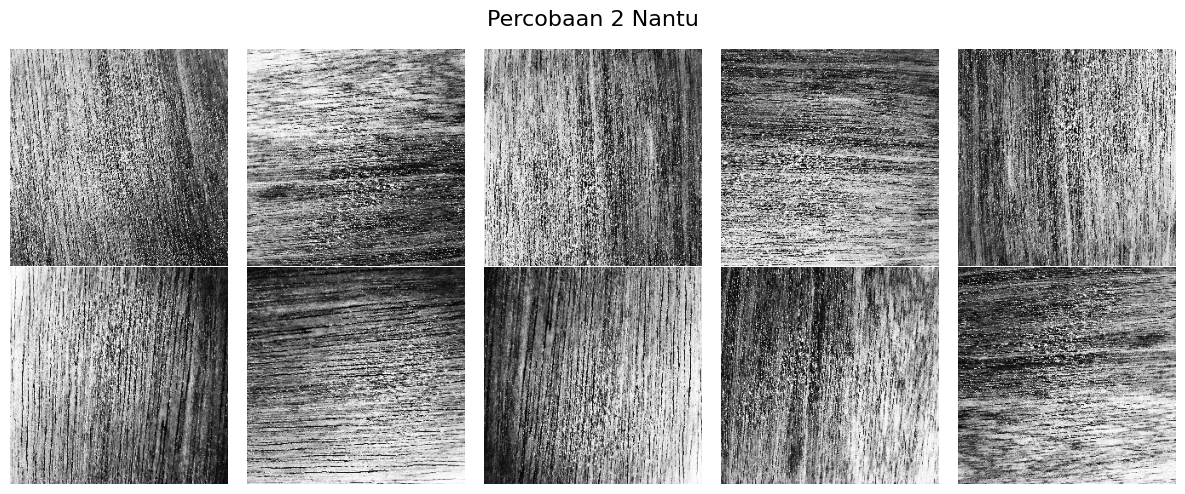

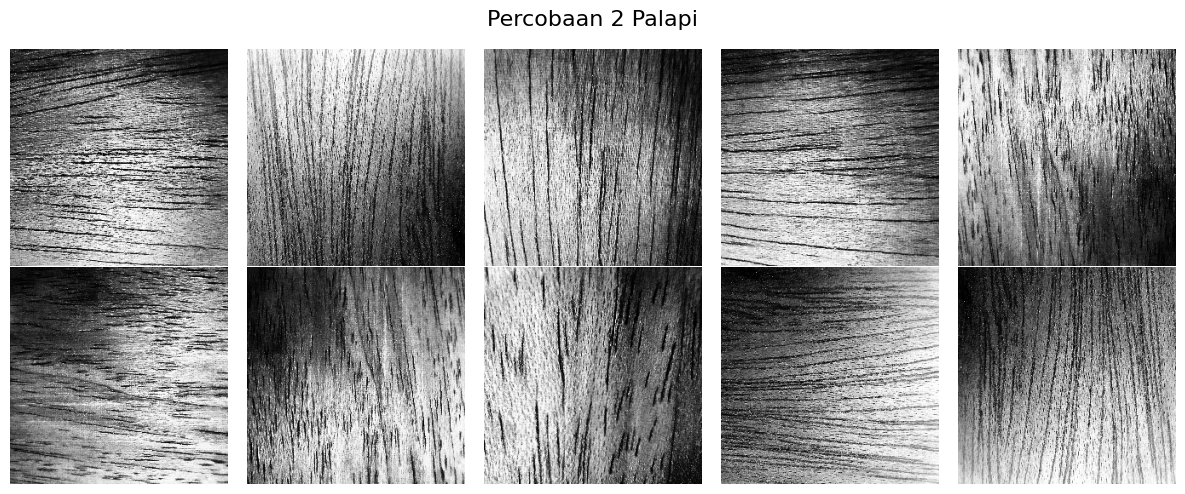

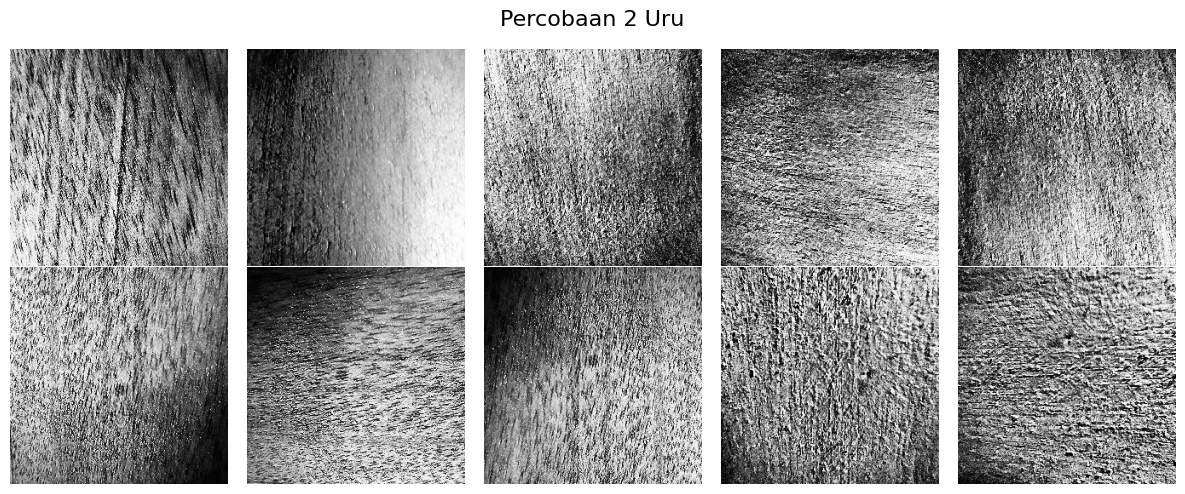

In [9]:
def percobaan2(img):
    img_resize = resize(img, 256, 256)
    img_gray = grayscale(img_resize)
    img_histogram = histogram_equalization(img_gray)
    return img_histogram

dataPreprocessed = [percobaan2(img) for img in data]  

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'Percobaan 2 {label}', fontsize=16)
    
    for k in range(10):
        row = k // 5
        col = k % 5
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9) 
    plt.show()

## Data Augmentation

Augmentasi dilakukan untuk memperbanyak jumlah data dan menambah variasi citra tanpa perlu mengumpulkan data baru. Setiap citra asli menghasilkan tiga citra tambahan melalui tiga teknik, yaitu **flip horizontal**, **flip vertikal**, dan **Gaussian blur**. Flip horizontal dan vertikal mensimulasikan variasi orientasi serat kayu, sedangkan Gaussian blur mensimulasikan kondisi citra yang kurang tajam. Dengan demikian, setiap satu citra asli menghasilkan empat citra total, sehingga jumlah dataset meningkat empat kali lipat.

Augmentasi yang diterapkan dipilih karena relevan dengan karakteristik citra serat kayu, di mana pola tekstur kayu secara alami dapat muncul dari berbagai arah. Namun perlu diperhatikan bahwa teknik augmentasi yang terlalu seragam tetap berpotensi menghasilkan sampel yang kurang bervariasi, sehingga kontribusinya terhadap peningkatan performa model perlu diverifikasi melalui evaluasi lebih lanjut.

In [10]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):
    img = data[i]
    label = labels[i]
    fname = file_name[i]
    
    # Citra Asli
    data_augmented.append(img)
    labels_augmented.append(label)
    file_name_augmented.append(fname)
    
    # 1. Flip Horizontal
    img_flip_h = cv.flip(img, 1)
    data_augmented.append(img_flip_h)
    labels_augmented.append(label)
    file_name_augmented.append('flip_h_' + fname)
    
    # 2. Flip Vertikal
    img_flip_v = cv.flip(img, 0)
    data_augmented.append(img_flip_v)
    labels_augmented.append(label)
    file_name_augmented.append('flip_v_' + fname)
    
    # 3. Blur (Gaussian)
    img_blur = cv.GaussianBlur(img, (5, 5), 0)
    data_augmented.append(img_blur)
    labels_augmented.append(label)
    file_name_augmented.append('blur_' + fname)

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)

In [11]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  315
Data setelah augmentasi:  1260


## Feature Extraction

Ekstraksi fitur dilakukan menggunakan Gray Level Co-occurrence Matrix (GLCM), yaitu metode yang merepresentasikan karakteristik tekstur citra berdasarkan hubungan spasial intensitas antar piksel. Matriks GLCM dihitung pada empat sudut orientasi, yaitu **0°, 45°, 90°, dan 135°**, dengan jarak piksel `distances=[1, 2, 3]` menggunakan pengaturan `symmetric=True` dan `normed=True`.

Dari setiap matriks GLCM yang dihasilkan, diekstrak tujuh fitur tekstur, yaitu **Contrast**, **Correlation**, **Energy**, **Homogeneity**, **Dissimilarity**, **ASM**, dan **Entropy**. Karena perhitungan dilakukan pada empat sudut, setiap fitur menghasilkan empat nilai berbeda sesuai orientasinya, sehingga total terdapat 28 fitur tekstur per citra.

Kelebihan GLCM terletak pada kemampuannya merepresentasikan tekstur secara kuantitatif dari berbagai arah, sehingga pola serat kayu yang memiliki orientasi berbeda tetap dapat tertangkap dengan baik. Namun, kualitas fitur yang dihasilkan sangat bergantung pada parameter yang digunakan serta kualitas preprocessing sebelumnya.

In [12]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm_matrix = graycomatrix(
    image,
    distances=[1,2,3],
    angles=angles,
    levels=256,
    symmetric=True,
    normed=True
)

    return glcm_matrix

In [13]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [14]:
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan2')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,8757.964844,0.195410,0.013677,0.025411,71.053232,0.000187,10.042072,percobaan2
1,3309.055852,0.697635,0.029530,0.073842,39.559620,0.000872,8.708332,percobaan2
2,8569.543015,0.209421,0.017967,0.029863,70.110539,0.000323,9.562542,percobaan2
3,4689.574265,0.566856,0.020495,0.050661,48.305668,0.000420,9.425574,percobaan2
4,8525.809972,0.212221,0.017978,0.030348,69.915855,0.000323,9.563302,percobaan2
...,...,...,...,...,...,...,...,...
310,1507.168214,0.861494,0.016590,0.069315,26.266927,0.000275,9.765625,percobaan2
311,3403.052007,0.686906,0.013564,0.043761,41.152007,0.000184,10.008962,percobaan2
312,2132.688312,0.802818,0.012158,0.045111,33.867632,0.000148,10.219724,percobaan2
313,1063.367570,0.901774,0.014784,0.073968,22.535616,0.000219,9.957721,percobaan2


In [15]:
for i in range(len(dataPreprocessed)):
    dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8)

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks GLCM untuk setiap sudut! ---")

--- Sukses membuat matriks GLCM untuk setiap sudut! ---


In [16]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print("--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---")

--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---


## Penyimpanan Hasil Ekstraksi

Seluruh nilai fitur GLCM yang telah diekstrak dari keempat sudut orientasi disusun ke dalam sebuah DataFrame dengan 28 kolom fitur, mencakup Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, dan Correlation masing-masing pada sudut 0°, 45°, 90°, dan 135°. DataFrame tersebut kemudian dilengkapi dengan informasi nama file dan label kelas, lalu disimpan ke dalam file CSV bernama `hasil_ekstraksi_percobaan3.csv`.

Penyimpanan hasil ekstraksi dalam format CSV memungkinkan data fitur dapat diakses kembali kapan saja tanpa perlu mengulang proses komputasi GLCM dari awal, sehingga tahap pelatihan dan evaluasi model dapat dilakukan secara lebih efisien dan fleksibel.

In [17]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [18]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,nantu_train (1).jpg,Nantu,8757.964844,8427.681000,5477.890579,8253.628297,0.025411,0.026550,0.040693,0.025297,...,0.000226,0.000186,0.013677,0.013707,0.015030,0.013620,0.195410,0.226073,0.496703,0.242049
1,nantu_train (10).jpg,Nantu,3309.055852,6627.091795,6754.096308,6553.573733,0.073842,0.043009,0.044713,0.044887,...,0.000609,0.000618,0.029530,0.024480,0.024681,0.024860,0.697635,0.394206,0.382328,0.400926
2,nantu_train (100).jpg,Nantu,8569.543015,8298.131780,4656.556832,8230.722322,0.029863,0.030355,0.051707,0.031152,...,0.000422,0.000325,0.017967,0.017971,0.020554,0.018036,0.209421,0.234585,0.570366,0.240819
3,nantu_train (101).jpg,Nantu,4689.574265,8289.645582,8537.494240,8200.986113,0.050661,0.030044,0.030245,0.031061,...,0.000322,0.000323,0.020495,0.017928,0.017932,0.017959,0.566856,0.234430,0.211579,0.242616
4,nantu_train (102).jpg,Nantu,8525.809972,8278.209658,4661.035218,8189.770365,0.030348,0.030572,0.052194,0.030512,...,0.000423,0.000326,0.017978,0.017983,0.020574,0.018047,0.212221,0.235069,0.569252,0.243239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,uru_train (95).jpg,Uru,1507.168214,3279.461776,3413.984804,3290.645921,0.069315,0.043776,0.042951,0.043117,...,0.000182,0.000183,0.016590,0.013583,0.013501,0.013528,0.861494,0.697894,0.685778,0.696852
311,uru_train (96).jpg,Uru,3403.052007,3266.432572,1489.596308,3279.710973,0.043761,0.043809,0.070426,0.043286,...,0.000280,0.000184,0.013564,0.013643,0.016726,0.013571,0.686906,0.699208,0.863162,0.697974
312,uru_train (97).jpg,Uru,2132.688312,2081.815010,1043.200659,2070.734010,0.045111,0.043909,0.073209,0.043476,...,0.000223,0.000147,0.012158,0.012144,0.014928,0.012143,0.802818,0.807287,0.903593,0.808307
313,uru_train (98).jpg,Uru,1063.367570,2099.903176,2155.680990,2091.439369,0.073968,0.044753,0.045024,0.043476,...,0.000146,0.000145,0.014784,0.012089,0.012090,0.012047,0.901774,0.805565,0.800654,0.806344


## Feature Selection

Seleksi fitur dilakukan untuk menghilangkan fitur-fitur yang redundan, yaitu fitur yang memiliki korelasi terlalu tinggi satu sama lain sehingga dianggap membawa informasi yang serupa. Proses ini menggunakan metode **correlation-based feature selection** dengan threshold sebesar **0.90**, artinya apabila dua fitur memiliki nilai korelasi absolut ≥ 0.90, maka salah satu fitur akan dihapus dari dataset.

Hasil seleksi kemudian divisualisasikan menggunakan **heatmap korelasi** untuk memastikan bahwa fitur-fitur yang tersisa memiliki tingkat korelasi yang lebih rendah antar satu sama lain. Proses ini penting karena fitur yang terlalu berkorelasi dapat menyebabkan model menjadi tidak stabil dan memperlambat proses pelatihan tanpa memberikan tambahan informasi yang berarti.

Jumlah fitur sebelum seleksi: 28
Jumlah fitur setelah seleksi: 11


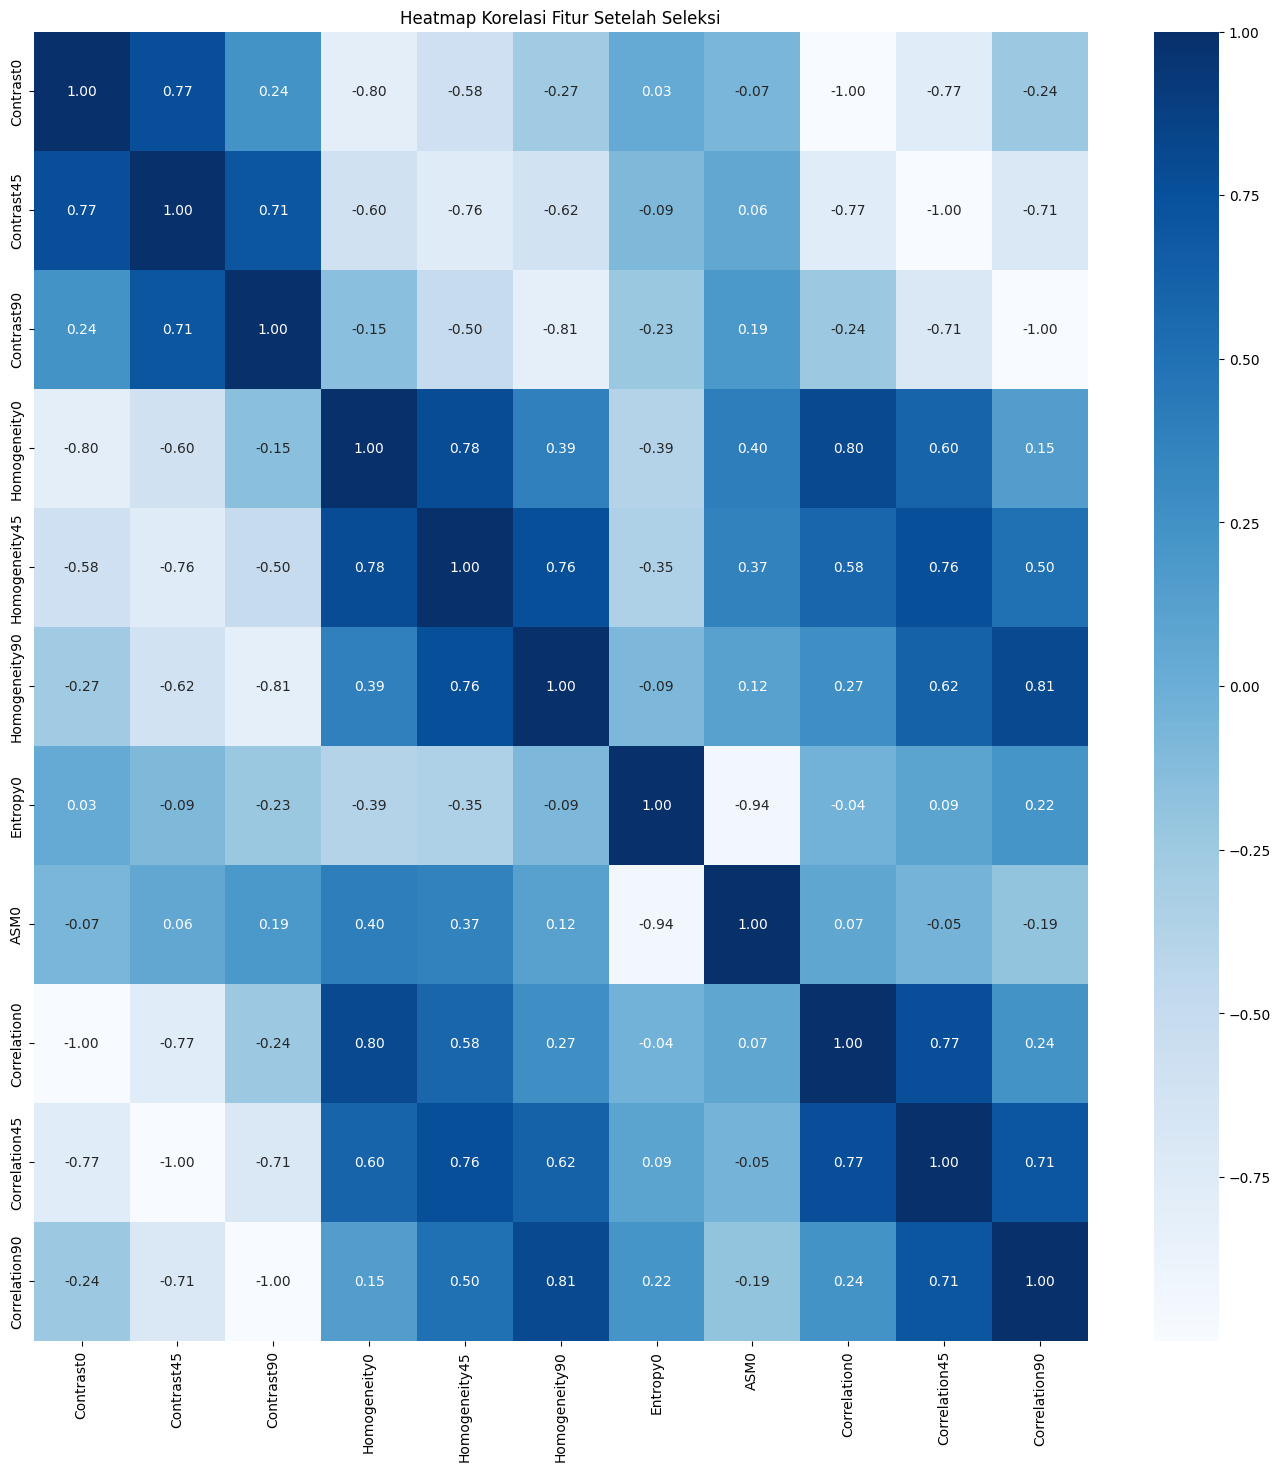

In [19]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.90
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Jumlah fitur sebelum seleksi: {correlation.shape[0]}")
print(f"Jumlah fitur setelah seleksi: {x_new.shape[1]}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Setelah Seleksi')
plt.show()

## SPLITTING DATA

Data fitur yang telah diseleksi dibagi menjadi dua subset menggunakan `train_test_split`, yaitu **data latih** sebesar 80% dan **data uji** sebesar 20%. Parameter `random_state=42` digunakan untuk memastikan hasil pembagian data konsisten setiap kali kode dijalankan. Selain itu, parameter `stratify=y` diterapkan untuk menjaga proporsi setiap kelas tetap seimbang antara data latih dan data uji, sehingga tidak terjadi ketimpangan distribusi label yang dapat mempengaruhi performa model.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(252, 11)
(63, 11)
(252,)
(63,)


## Normalisasi

Kode ini menormalisasi fitur GLCM yang telah diekstrak dari citra serat kayu Nantu, Palapi, dan Uru menggunakan Z-score standardization. Karena ketujuh fitur GLCM seperti Contrast, Entropy, dan Correlation memiliki rentang nilai yang berbeda-beda secara signifikan, normalisasi diperlukan agar tidak ada satu fitur pun yang mendominasi proses pelatihan model hanya karena skala nilainya lebih besar.

Nilai rata-rata dan standar deviasi dihitung dari `X_train`, yaitu 80% data fitur hasil ekstraksi, kemudian nilai yang sama digunakan untuk menormalisasi `X_test` yang merupakan 20% sisanya. Pendekatan ini memastikan bahwa skala normalisasi konsisten antara data latih dan data uji, sehingga model dapat mengevaluasi citra serat kayu secara objektif tanpa terpengaruh informasi dari data uji.

In [21]:
X_train = np.array(X_train)
X_test = np.array(X_test)

X_train_scaled = (X_train - X_train.mean()) / X_train.std()
X_test_scaled = (X_test - X_train.mean()) / X_train.std()

X_train = X_train_scaled
X_test = X_test_scaled

## MODELING

### DEFINE MODEL

Tiga model klasifikasi didefinisikan untuk membedakan karakteristik tekstur citra serat kayu Nantu, Palapi, dan Uru. **Random Forest** dibangun dengan 5 pohon keputusan, **SVM** menggunakan kernel RBF untuk menangani pola tekstur yang bersifat non-linear, dan **KNN** mengklasifikasikan citra berdasarkan 5 tetangga terdekat dalam ruang fitur GLCM.

Fungsi `generateClassificationReport` didefinisikan untuk menampilkan hasil evaluasi ketiga model secara seragam, mencakup **classification report** per kelas Nantu, Palapi, dan Uru, **confusion matrix** untuk melihat pola kesalahan klasifikasi antar kelas, serta nilai **accuracy** keseluruhan model.

In [22]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### TRAIN RANDOM FOREST CLASSIFER

Data fitur dikonversi ke array NumPy dan di-reshape menjadi format dua dimensi agar kompatibel dengan model. Normalisasi Z-score kemudian diterapkan menggunakan rata-rata dan standar deviasi dari data latih, yang juga digunakan untuk menormalisasi data uji guna menghindari data leakage.

Model Random Forest dilatih menggunakan `rf.fit(X_train, y_train)` pada data fitur GLCM yang telah dinormalisasi. Evaluasi dilakukan pada dua subset, yaitu **training set** untuk mengukur seberapa baik model mempelajari data latih, dan **testing set** untuk mengukur kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya. Hasil evaluasi ditampilkan menggunakan fungsi `generateClassificationReport` yang mencakup classification report, confusion matrix, dan nilai accuracy untuk masing-masing subset.

In [23]:
X_train = np.array(X_train)
X_test = np.array(X_test)

X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_train = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_train)

print("\n------Testing Set------")
y_pred_test = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_test)

------Training Set------
              precision    recall  f1-score   support

       Nantu       0.99      0.98      0.98        84
      Palapi       0.98      0.99      0.98        84
         Uru       0.99      0.99      0.99        84

    accuracy                           0.98       252
   macro avg       0.98      0.98      0.98       252
weighted avg       0.98      0.98      0.98       252

[[82  1  1]
 [ 1 83  0]
 [ 0  1 83]]
Accuracy: 0.9841269841269841

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.61      0.81      0.69        21
      Palapi       0.84      0.76      0.80        21
         Uru       0.88      0.67      0.76        21

    accuracy                           0.75        63
   macro avg       0.77      0.75      0.75        63
weighted avg       0.77      0.75      0.75        63

[[17  3  1]
 [ 4 16  1]
 [ 7  0 14]]
Accuracy: 0.746031746031746


### TRAIN SVM CLASSIFER

Model SVM dilatih menggunakan `svm.fit(X_train, y_train)` pada data fitur GLCM yang telah dinormalisasi sebelumnya. Evaluasi dilakukan pada dua subset, yaitu **training set** untuk mengukur kemampuan model dalam mempelajari pola tekstur data latih, dan **testing set** untuk mengukur kemampuan generalisasi model dalam mengklasifikasikan citra serat kayu Nantu, Palapi, dan Uru yang belum pernah dilihat sebelumnya. Hasil evaluasi keduanya ditampilkan menggunakan fungsi `generateClassificationReport` yang mencakup classification report, confusion matrix, dan nilai accuracy.

In [24]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       0.53      0.32      0.40        84
      Palapi       0.49      0.96      0.65        84
         Uru       0.43      0.19      0.26        84

    accuracy                           0.49       252
   macro avg       0.49      0.49      0.44       252
weighted avg       0.49      0.49      0.44       252

[[27 38 19]
 [ 1 81  2]
 [23 45 16]]
Accuracy: 0.49206349206349204

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.44      0.33      0.38        21
      Palapi       0.53      0.95      0.68        21
         Uru       0.44      0.19      0.27        21

    accuracy                           0.49        63
   macro avg       0.47      0.49      0.44        63
weighted avg       0.47      0.49      0.44        63

[[ 7 10  4]
 [ 0 20  1]
 [ 9  8  4]]
Accuracy: 0.49206349206349204


### Train KNN Classifier

Model KNN menggunakan `knn.fit(X_train, y_train)` pada data fitur GLCM yang telah dinormalisasi. Evaluasi dilakukan pada dua subset, yaitu **training set** untuk mengukur seberapa baik model mengenali pola tekstur dari data latih, dan **testing set** untuk mengukur kemampuan model dalam mengklasifikasikan citra serat kayu Nantu, Palapi, dan Uru pada data yang belum pernah dilihat sebelumnya. Hasil evaluasi ditampilkan menggunakan fungsi `generateClassificationReport` yang mencakup classification report, confusion matrix, dan nilai accuracy.

In [25]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       0.70      0.70      0.70        84
      Palapi       0.86      0.81      0.83        84
         Uru       0.72      0.76      0.74        84

    accuracy                           0.76       252
   macro avg       0.76      0.76      0.76       252
weighted avg       0.76      0.76      0.76       252

[[59  6 19]
 [10 68  6]
 [15  5 64]]
Accuracy: 0.7579365079365079

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.42      0.67      0.52        21
      Palapi       0.67      0.57      0.62        21
         Uru       0.67      0.38      0.48        21

    accuracy                           0.54        63
   macro avg       0.59      0.54      0.54        63
weighted avg       0.59      0.54      0.54        63

[[14  5  2]
 [ 7 12  2]
 [12  1  8]]
Accuracy: 0.5396825396825397


### EVALUASI DENGAN CONFUSSION MATRIX

Fungsi `plot_confusion_matrix` didefinisikan untuk menampilkan confusion matrix dalam bentuk visual menggunakan `ConfusionMatrixDisplay` dengan warna biru. Confusion matrix divisualisasikan untuk ketiga model, yaitu **Random Forest**, **SVM**, dan **KNN**, masing-masing menggunakan hasil prediksi pada data uji.

Visualisasi ini memudahkan analisis pola kesalahan klasifikasi antar kelas Nantu, Palapi, dan Uru, seperti kelas mana yang sering tertukar satu sama lain, sehingga memberikan gambaran yang lebih intuitif dibandingkan hanya membaca nilai numerik dari classification report.

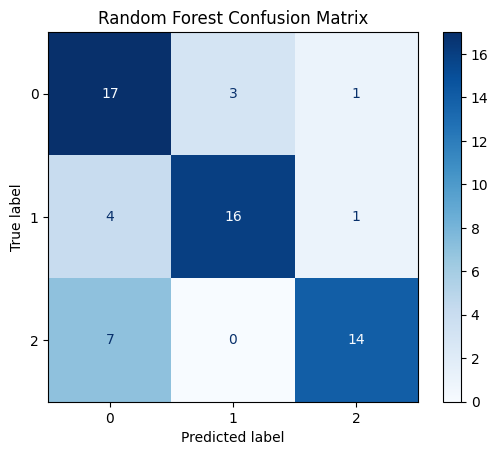

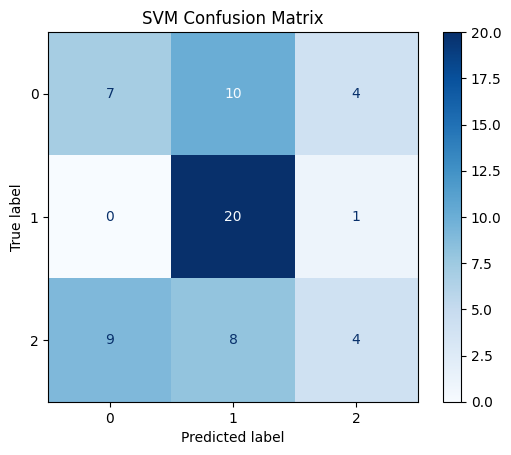

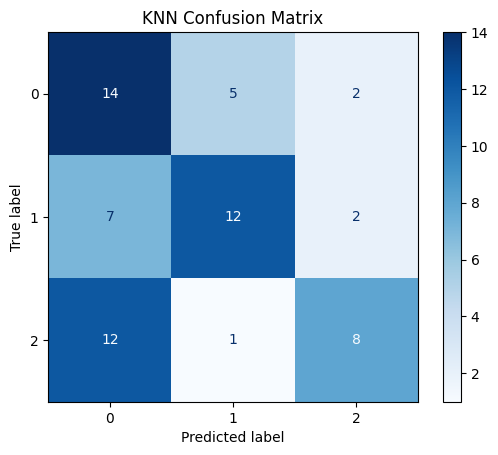

In [26]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")